In [5]:
import polars as pl
import pyrsm as rsm

# Load the diamonds data
df = pl.read_parquet("/Users/vnijs/gh/pyrsm/examples/data/model/diamonds.parquet")

# Fit the regression: price ~ carat + clarity + cut + color + depth + table
reg = rsm.model.regress(
    {"diamonds": df},
    rvar="price",
    evar=["carat", "clarity", "cut", "color", "depth", "table"],
)

reg.summary(rmse=True, ssq=True)


Linear regression (OLS)
Data                 : diamonds
Response variable    : price
Explanatory variables: carat, clarity, cut, color, depth, table
Null hyp.: the effect of x on price is zero
Alt. hyp.: the effect of x on price is not zero

┌────────────────┬─────────────┬───────────┬─────────┬─────────┬─────┐
│ index          ┆ coefficient ┆ std.error ┆ t.value ┆ p.value ┆     │
╞════════════════╪═════════════╪═══════════╪═════════╪═════════╪═════╡
│ Intercept      ┆ -6140.137   ┆ 1506.876  ┆ -4.075  ┆ < .001  ┆ *** │
│ clarity[SI2]   ┆ 2619.501    ┆ 181.86    ┆ 14.404  ┆ < .001  ┆ *** │
│ clarity[SI1]   ┆ 3535.264    ┆ 181.224   ┆ 19.508  ┆ < .001  ┆ *** │
│ clarity[VS2]   ┆ 4134.993    ┆ 182.746   ┆ 22.627  ┆ < .001  ┆ *** │
│ clarity[VS1]   ┆ 4440.273    ┆ 185.372   ┆ 23.953  ┆ < .001  ┆ *** │
│ clarity[VVS2]  ┆ 4948.51     ┆ 190.874   ┆ 25.925  ┆ < .001  ┆ *** │
│ clarity[VVS1]  ┆ 4939.32     ┆ 194.63    ┆ 25.378  ┆ < .001  ┆ *** │
│ clarity[IF]    ┆ 5256.258    ┆ 211.61    ┆ 24.

In [6]:
# Log-log specification: log-transform price and carat
df_log = df.with_columns(
    price_ln=pl.col("price").log(),
    carat_ln=pl.col("carat").log(),
)

# Fit: ln(price) ~ ln(carat) + clarity + cut + color + depth + table
reg_log = rsm.model.regress(
    {"diamonds": df_log},
    rvar="price_ln",
    evar=["carat_ln", "clarity", "cut", "color", "depth", "table"],
)

reg_log.summary(rmse=True, ssq=True)

Linear regression (OLS)
Data                 : diamonds
Response variable    : price_ln
Explanatory variables: carat_ln, clarity, cut, color, depth, table
Null hyp.: the effect of x on price_ln is zero
Alt. hyp.: the effect of x on price_ln is not zero

┌────────────────┬─────────────┬───────────┬─────────┬─────────┬─────┐
│ index          ┆ coefficient ┆ std.error ┆ t.value ┆ p.value ┆     │
╞════════════════╪═════════════╪═══════════╪═════════╪═════════╪═════╡
│ Intercept      ┆ 7.987       ┆ 0.183     ┆ 43.677  ┆ < .001  ┆ *** │
│ clarity[SI2]   ┆ 0.413       ┆ 0.022     ┆ 18.738  ┆ < .001  ┆ *** │
│ clarity[SI1]   ┆ 0.578       ┆ 0.022     ┆ 26.349  ┆ < .001  ┆ *** │
│ clarity[VS2]   ┆ 0.729       ┆ 0.022     ┆ 32.978  ┆ < .001  ┆ *** │
│ clarity[VS1]   ┆ 0.797       ┆ 0.022     ┆ 35.533  ┆ < .001  ┆ *** │
│ clarity[VVS2]  ┆ 0.925       ┆ 0.023     ┆ 39.965  ┆ < .001  ┆ *** │
│ clarity[VVS1]  ┆ 1.01        ┆ 0.024     ┆ 42.789  ┆ < .001  ┆ *** │
│ clarity[IF]    ┆ 1.101       ┆ 0.0

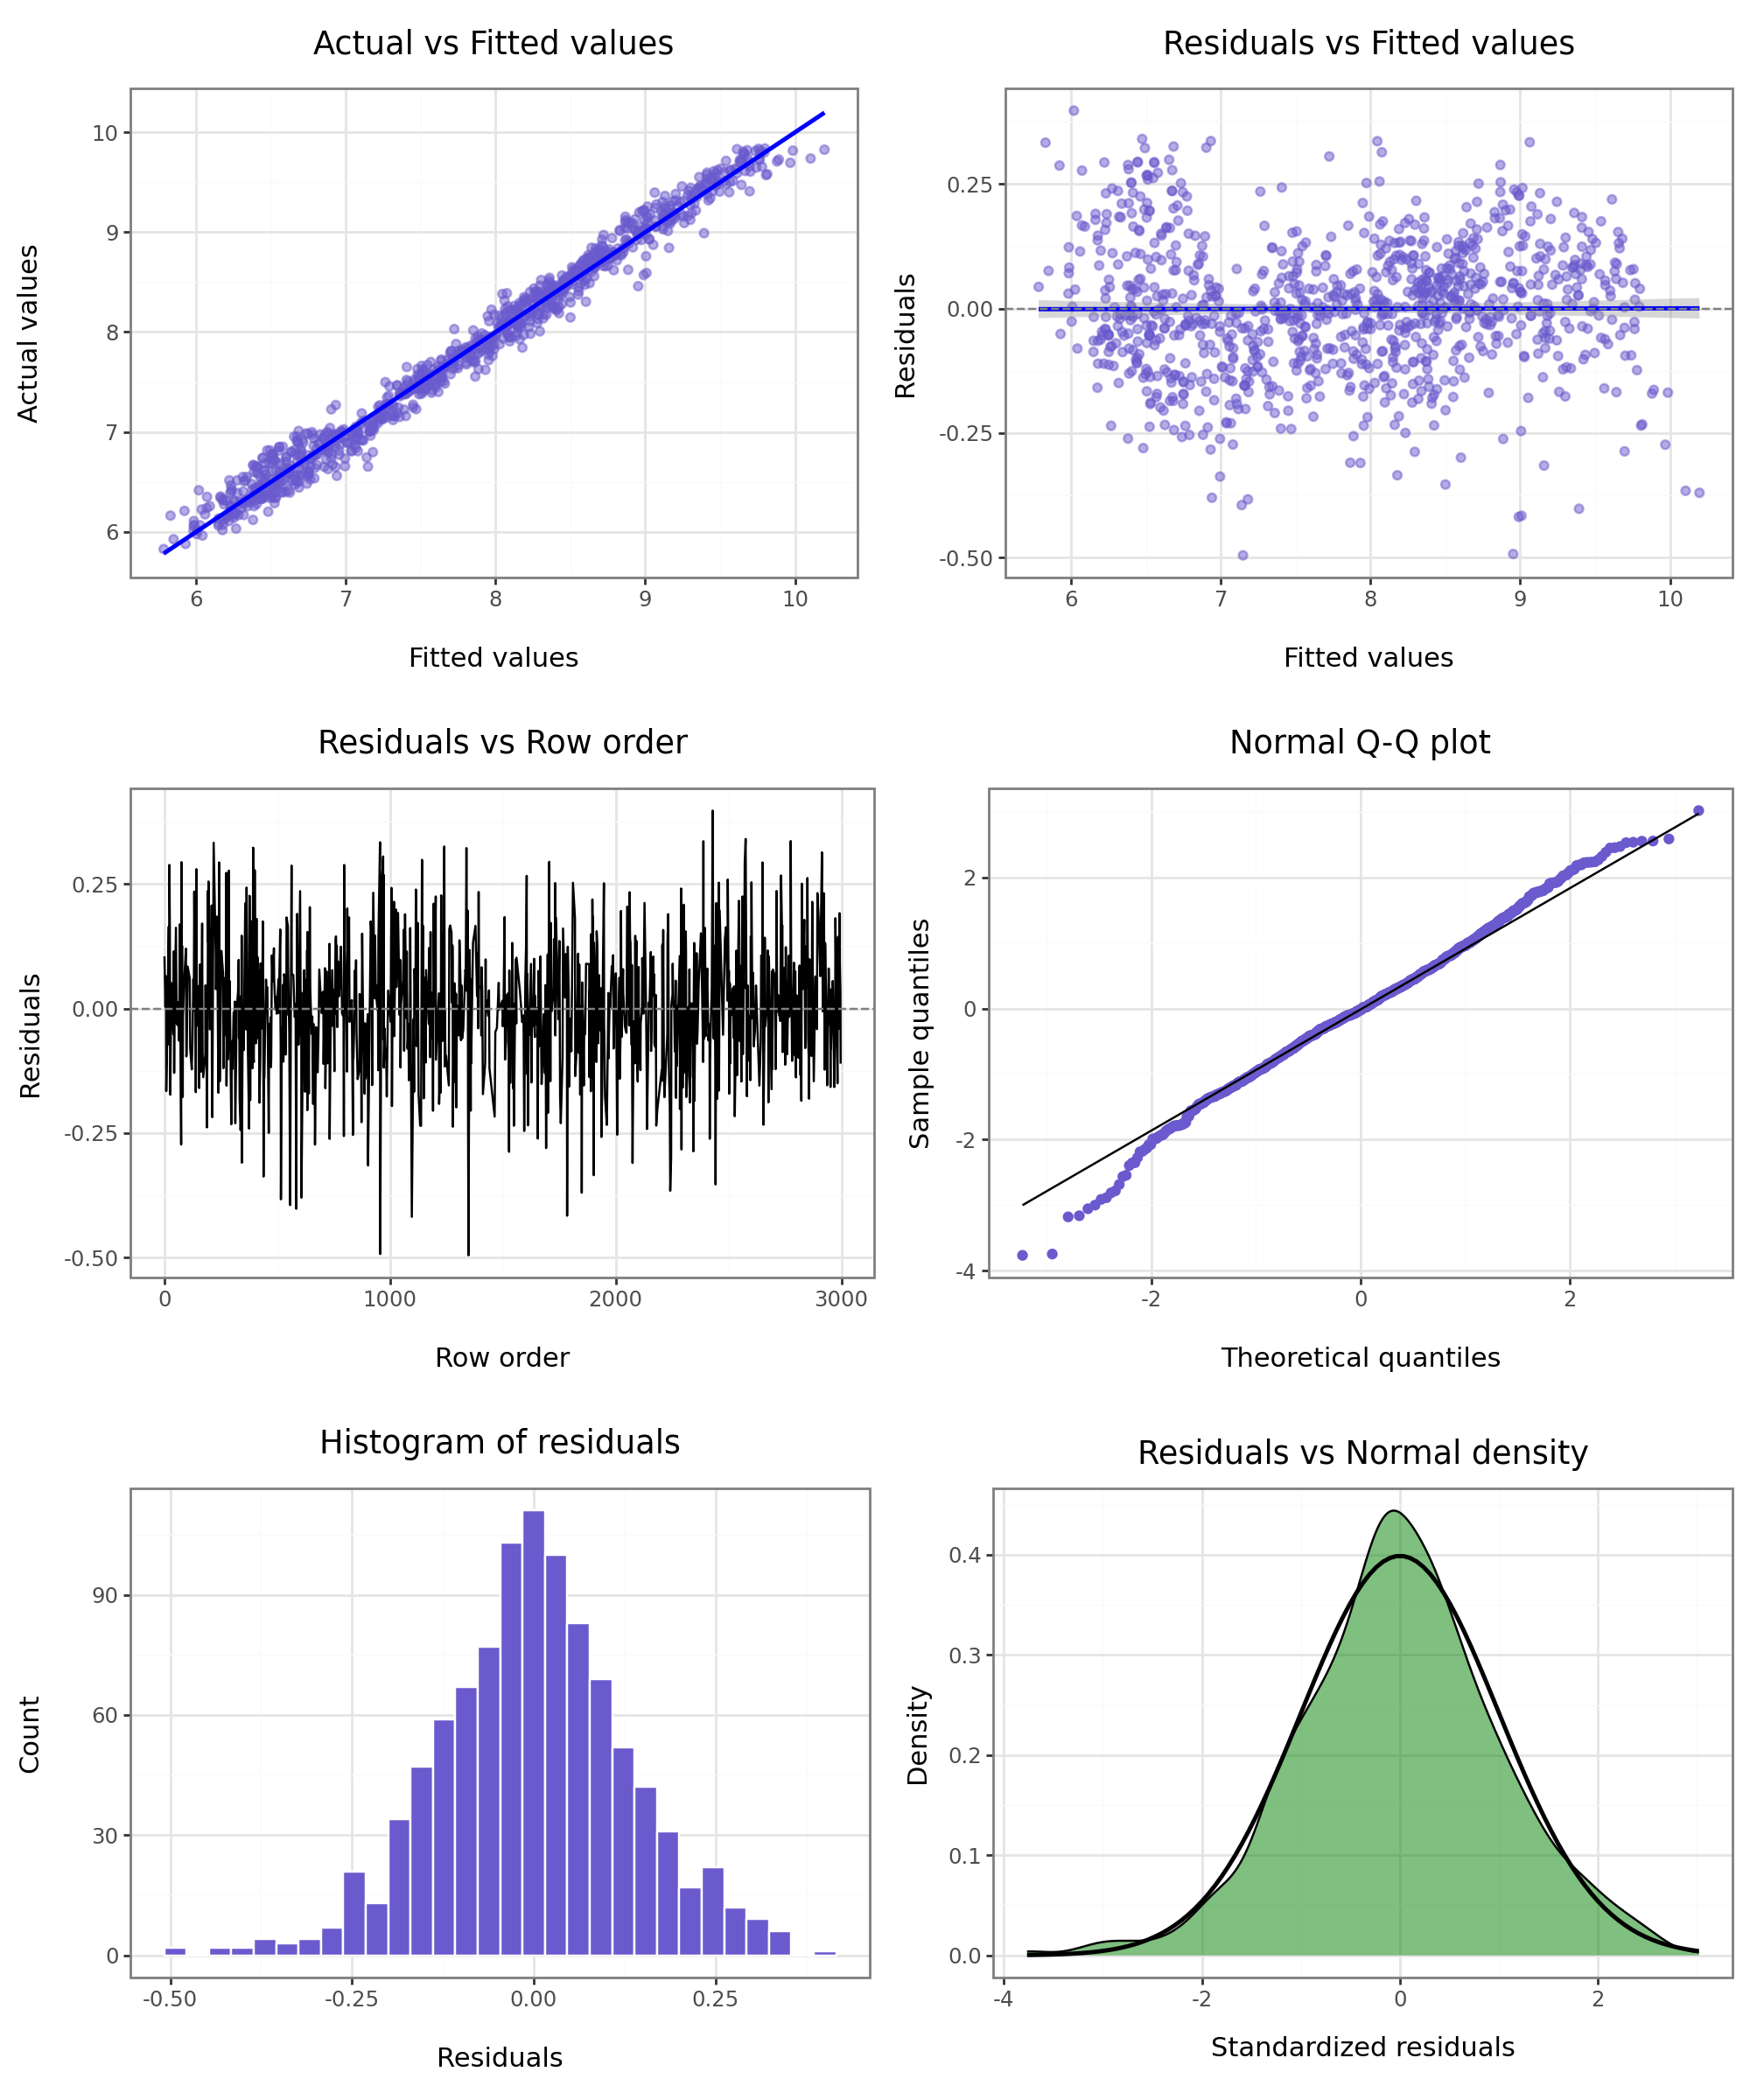

In [7]:
reg_log.plot("dashboard")